In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

sys.path.append("..")

import importlib
import src.preprocessing.pipeline as pl
importlib.reload(pl)

build_preprocessing_pipeline = pl.build_preprocessing_pipeline
get_feature_lists = pl.get_feature_lists

set_config(transform_output="pandas")

DATA_PATH = "../data/processed/health_index_ae_dataset.csv"
MODELS_PATH = "../models"
REPORTS_PATH = "../reports"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(24042, 24)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,...,temp_gap,vibration_rpm_interaction,pressure_current_interaction,vibration_delta,temperature_delta,anomaly_trend_raw,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,...,35.61,697.329,120.360,0.00,0.00,0.000,0.000004,0.004974,0.995026,good
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,...,30.38,674.700,125.080,-0.06,-8.93,0.000,0.000004,0.004555,0.995445,good
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,...,36.10,612.517,NaN,-0.04,9.12,3.648,0.000003,0.003181,0.996819,good
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,...,29.64,661.504,108.254,0.05,-6.66,0.030,0.000003,0.003954,0.996046,good
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,...,30.59,776.072,98.568,0.12,-1.65,0.072,0.000003,0.003573,0.996427,good


In [3]:
target = "failure_within_24h"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64
failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64


In [4]:
numeric_features, categorical_features = get_feature_lists()
all_features = numeric_features + categorical_features

forbidden_cols = [
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost",
    "health_index_ae",
    "health_status",
    "reconstruction_error",
    "reconstruction_error_norm",
]

features = [
    col for col in all_features
    if col in df.columns and col not in forbidden_cols
]

X = df[features].copy()
y = df[target].copy()

print("Nombre de features :", len(features))
print(features)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Nombre de features : 15
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'machine_type', 'operating_mode']
Shape X : (24042, 15)
Shape y : (24042,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

print("\nRépartition train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition test :")
print(y_test.value_counts(normalize=True))

Train : (19233, 15) (19233,)
Test  : (4809, 15) (4809,)

Répartition train :
failure_within_24h
0    0.851921
1    0.148079
Name: proportion, dtype: float64

Répartition test :
failure_within_24h
0    0.851944
1    0.148056
Name: proportion, dtype: float64


In [6]:
preprocessor = build_preprocessing_pipeline()
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['vibration_rms', 'temperature_motor',
                                  'current_phase_avg', 'pressure_level', 'rpm',
                                  'hours_since_maintenance', 'ambient_temp',
                                  'temp_gap', 'vibration_rpm_interaction',
                                  'pressure_current_interaction',
                                  'vibration_delta', 'temperature_delta',
                                  'anomaly_trend_raw']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                       

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=42
    )
}

In [8]:
def compute_classification_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

In [9]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nTraining : {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = compute_classification_metrics(y_test, y_pred, y_proba)

    results.append({
        "Model": name,
        **metrics
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred
    probabilities[name] = y_proba

print("\nEntraînement terminé.")


Training : Logistic Regression

Training : Random Forest

Training : Gradient Boosting

Entraînement terminé.


In [10]:
def compute_classification_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

In [11]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nTraining : {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = compute_classification_metrics(y_test, y_pred, y_proba)

    results.append({
        "Model": name,
        **metrics
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred
    probabilities[name] = y_proba

print("\nEntraînement terminé.")


Training : Logistic Regression

Training : Random Forest

Training : Gradient Boosting

Entraînement terminé.


In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.943855,0.756381,0.915730,0.828463,0.985691
1,Gradient Boosting,0.942608,0.857377,0.734551,0.791225,0.977261
2,Logistic Regression,0.906218,0.628067,0.898876,0.739457,0.962174


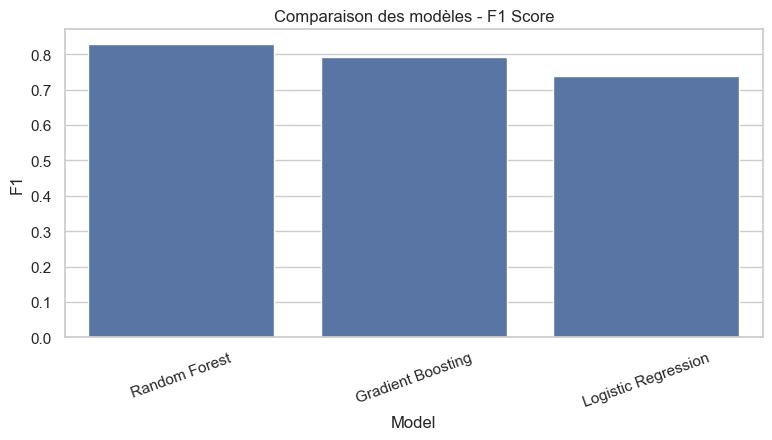

In [13]:
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="Model", y="F1")
plt.title("Comparaison des modèles - F1 Score")
plt.xticks(rotation=20)
plt.show()

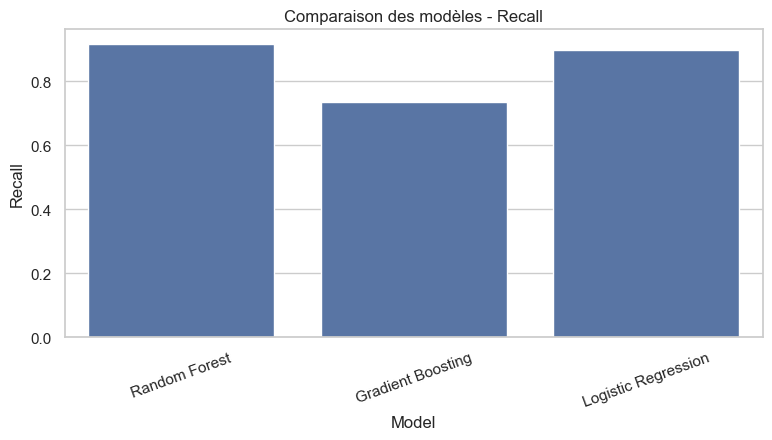

In [14]:
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="Model", y="Recall")
plt.title("Comparaison des modèles - Recall")
plt.xticks(rotation=20)
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle :", best_model_name)

Meilleur modèle : Random Forest


In [16]:
best_pred = predictions[best_model_name]

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      4097
           1       0.76      0.92      0.83       712

    accuracy                           0.94      4809
   macro avg       0.87      0.93      0.90      4809
weighted avg       0.95      0.94      0.95      4809



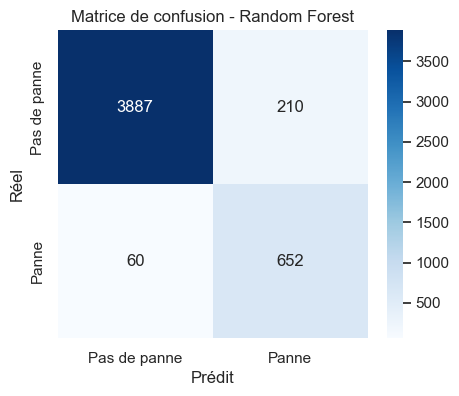

In [17]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pas de panne", "Panne"],
    yticklabels=["Pas de panne", "Panne"]
)
plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

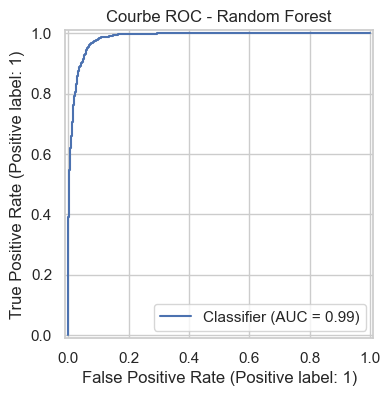

In [18]:
best_proba = probabilities[best_model_name]

RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title(f"Courbe ROC - {best_model_name}")
plt.show()

In [20]:
joblib.dump(best_model, "../models/failure_classifier.joblib")
print("Modèle de classification sauvegardé dans models/failure_classifier.joblib")

Modèle de classification sauvegardé dans models/failure_classifier.joblib


In [21]:
results_df.to_csv("../reports/model_comparison_failure24h.csv", index=False)
print("Résultats sauvegardés dans reports/model_comparison_failure24h.csv")

Résultats sauvegardés dans reports/model_comparison_failure24h.csv


In [22]:
sample_input = X_test.head(5)

sample_pred = best_model.predict(sample_input)
sample_proba = best_model.predict_proba(sample_input)[:, 1]

pd.DataFrame({
    "failure_reel": y_test.head(5).values,
    "failure_pred": sample_pred,
    "probability_failure": sample_proba
})

,failure_reel,failure_pred,probability_failure
0,0,0,0.046655
1,1,1,0.763817
2,0,0,0.027247
3,0,0,0.045509
4,0,1,0.831980


## Conclusion de la prédiction de panne

Les modèles de classification ont permis de prédire efficacement les pannes dans les 24 heures.

Le modèle Random Forest obtient les meilleures performances globales, avec notamment un Recall élevé, ce qui permet de détecter la majorité des pannes réelles.

Les résultats montrent que le modèle est capable de distinguer efficacement les machines à risque des machines normales, ce qui constitue un atout important dans un contexte de maintenance prédictive.
